# Matplotlib Basics and Stateful Plotting


In [1]:
import numpy as np
import pandas as pd

# %pip install matplotlib   ### uncomment to install matplotlib if you don't have it already
import matplotlib.pyplot as plt

```{contents}
:local:
:depth: 2
```



```{index} Matplotlib
```
## Introduction

Matplotlib is the foundational plotting library in the Python ecosystem, originally developed by John D. Hunter to provide MATLAB-like plotting capabilities in Python. It offers a rich, programmatic interface for producing publication-quality 2D graphics. For a history and introduction of Matplotlib, see matplotlib.org's [History](https://matplotlib.org/stable/project/history.html) section.

For data scientists, Matplotlib is valuable both as a plotting tool and as the underlying engine for fine-grained customization when presentation quality and plot element control matter.

Matplotlib sits at a low level in the Python visualization stack:

1. Many higher-level libraries, such as Pandas plotting methods and Seaborn, build on top of it.
2. It interoperates smoothly with NumPy arrays and the broader scientific Python toolchain.
3. It can be used through two main interfaces:
   1. The **stateful pyplot API** is convenient for quick, one-off plots.
   2. The **object-oriented (OO) API** is the recommended default for most work because it makes figure and axes management explicit.

A useful rule of thumb is:

- Use `plt.plot()` for quick interactive work.
- Use `plt.subplots()` for most real plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

Matplotlib has excellent official documentation and examples at https://matplotlib.org/ (see the [Tutorials](https://matplotlib.org/stable/tutorials/index.html) and [Examples](https://matplotlib.org/stable/gallery/index.html)).


```{index} installing Matplotlib
```
### Installation 

You'll need to install matplotlib first with either using `pip` in the terminal:

    pip install matplotlib     ### in terminal with .venv enabled
or using `%pip` in the notebook:

    %pip install matplotlib    ### in Jupyter Notebook

Import the `matplotlib.pyplot` module with alias `plt`:
```python
import matplotlib.pyplot as plt
```

The usual headers for what we are learning so far look like this. The hidden setup cell at the top of this page already runs them; with Live Code active you can install missing packages when needed:

```python
import numpy as np
import pandas as pd

# %pip install matplotlib   ### uncomment to install matplotlib if you don't have it already
import matplotlib.pyplot as plt
```



```{index} stateful interface, object-oriented interface
```
### Two Styles of Matplotlib Syntax

There are two common styles of Matplotlib plotting:

1. **Stateful pyplot style**: concise and convenient for quick plots.
2. **Object-oriented (OO) style**: more explicit and easier to scale to multi-axes figures.



Note on rendering visualizations:

- In Jupyter notebooks, plots usually display automatically.
- Outside notebooks, you will often need `plt.show()` to display the figure window.
- In older Jupyter/IPython setups, `%matplotlib inline` may still be needed.



```{index} pyplot, stateful interface
```
## Stateful Matplotlib

Matplotlib has two ways of making plots, and "stateful" refers to the older, MATLAB-style one: the pyplot interface (`plt.*` functions) that silently keeps track of a "current figure" and "current axes" behind the scenes. Each `plt.*` call acts on whatever is current at that moment, so you never hold a reference to the object you're drawing on.

These functions, such as `plt.plot()`, `plt.xlabel()`, and `plt.title()`, build a figure step by step. This style is useful for quick exploration, but it becomes harder to manage as figures grow more complex.


```{index} pyplot commands, pandas plotting
```
### Basic Matplotlib Commands

The table below compares common `plt.plot()` tasks with the corresponding Pandas `df.plot()` usage.

| Task     | Matplotlib plt.plot()  | Pandas df.plot()                      | Notes                                                           |
|----------|------------------------|---------------------------------------|---------------------------------------------------------------|
| figsize  | `plt.figure(figsize)`  | `df.plot(figsize=(m, n))`             | Use `plt.figure()` to setup figure size before `plt.plot()`     |
| To plot  | `plt.plot(x, y)`       | `df.plot(x="x", y="y")` or `s.plot()` | Uses DataFrame/Series directly; x defaults to index if omitted. |
| X label  | `plt.xlabel("X")`      | `df.plot(xlabel=...)`                 | `df.plot(...)` returns an `Axes`; set labels on it.             |
| Y label  | `plt.ylabel("Y")`      | `df.plot(ylabel=...)`                 | Same pattern as label.                                          |
| Title    | `plt.title("My Plot")` | `df.plot(title="My Plot")`            | Pandas supports `title=` in `plot`                              |


Pandas `.plot()` is a convenience wrapper around Matplotlib for quick DataFrame visualization. Compared with `plt.plot()`, the main differences are:

| Feature | `plt.plot()` | Pandas `.plot()` |
|---------|--------------|-------------|
| Typical use | Fine-grained, figure-level control | Fast EDA from DataFrame/Series |
| Built on | Core matplotlib | Wrapper around matplotlib |
| Customization | Full control | Limited, but can access underlying axes |
| Data Input | Expects x/y arrays | Pandas columns/index |

```{index} line plot (plt.plot), scatter plot (plt.scatter)
```
### First Plots

Let's walk through a simple example: six months of revenue for a small retailer, stored in two NumPy arrays. Lists work too, but you'll usually pass NumPy arrays or Pandas columns, which behave like arrays. The data we want to plot:

In [2]:
import numpy as np

month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

print(f"month {type(month)}: {month}")
print(f"revenue {type(revenue)}: {revenue}")

month <class 'numpy.ndarray'>: [1 2 3 4 5 6]
revenue <class 'numpy.ndarray'>: [110 104 118 121 125 119]


The following code creates a basic line plot:
- `plt.figure()`
- `plt.plot()`

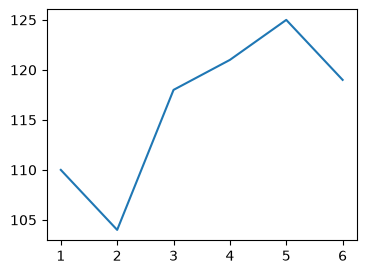

In [3]:
plt.figure(figsize=(4,3))
plt.plot(month, revenue)

You can also create a scatter plot with `plt.scatter()`. A scatter plot suits pairs of values, such as each month's ad spend and sales:

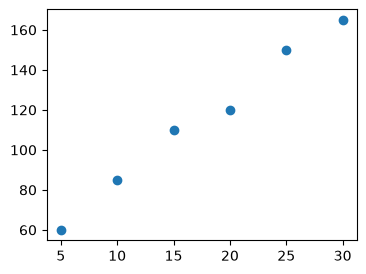

In [4]:
ad_spend = np.array([5, 10, 15, 20, 25, 30])        ### monthly ad spend in $K
sales = np.array([60, 85, 110, 120, 150, 165])      ### monthly sales in $K

plt.figure(figsize=(4,3))
plt.scatter(ad_spend, sales)

```{index} title, axis label, legend
```
### Labels/Title/Legend

Common plot customizations include:

- color
- label (legend information)
- x-axis and y-axis labels
- title
- legend (built from labels)


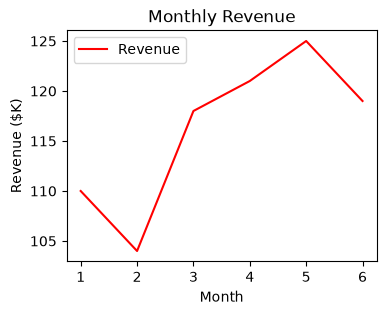

In [5]:
# plt.plot(month, revenue, 'r')       ### 'r' means color red
# plt.plot(month, revenue, c='r')     ### same as above, we saw this in Pandas plot

plt.figure(figsize=(4,3))
plt.plot(month, revenue, c='red', label='Revenue')   ### label= is what the legend shows
plt.xlabel('Month')                  ### in Pandas plot, this is automatic from column names
plt.ylabel('Revenue ($K)')           ### in Pandas plot, this is automatic from column names
plt.title('Monthly Revenue')         ### in Pandas plot, this is "title="
plt.legend()                         ### to show the label we set above

The same plot can be created with Pandas plotting:


<Axes: title={'center': 'Monthly Revenue'}, xlabel='Month', ylabel='Revenue ($K)'>

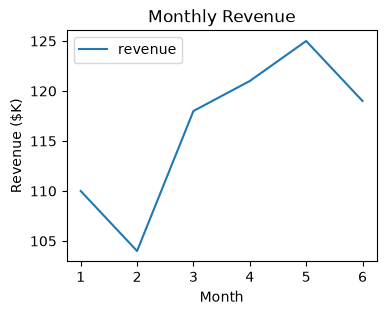

In [6]:
df = pd.DataFrame({'month': month, 'revenue': revenue})   ### DataFrame with two columns

# df.plot(x='month', y='revenue', kind="line")   ### line plot is default in Pandas; axes is automatically created
# df.plot.line(x='month', y='revenue')           ### same as above
# df.plot(x='month', y='revenue')                ### same as above

df.plot(x='month', y='revenue', xlabel='Month', ylabel='Revenue ($K)', title='Monthly Revenue', figsize=(4,3))
### all labels and title can be set in df.plot() directly or from dataframe column names

In [7]:
### Exercise: Basic plt.plot() with Customization
#   1. Create week = np.arange(1, 9) and
#      visits = np.array([820, 870, 910, 890, 960, 1010, 990, 1080]).
#   2. Use plt.figure(figsize=(4, 3)) to set the figure size.
#   3. Plot week vs visits in red with the label "Visits".
#   4. Add an x-label "Week", y-label "Website Visits", and title "Weekly Website Visits".
#   5. Call plt.legend() to show the label.
### Your code starts here.




### Your code ends here.

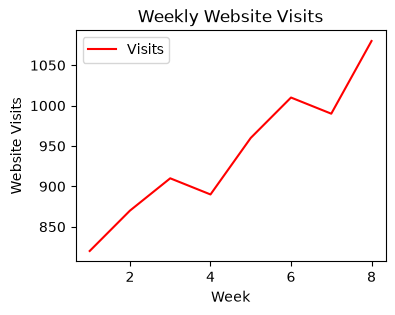

In [8]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

week = np.arange(1, 9)
visits = np.array([820, 870, 910, 890, 960, 1010, 990, 1080])

plt.figure(figsize=(4, 3))
plt.plot(week, visits, 'r-', label='Visits')
plt.xlabel('Week')
plt.ylabel('Website Visits')
plt.title('Weekly Website Visits')
plt.legend()
plt.show()


```{index} subplot (plt.subplot)
```
## Multiple Plots with `plt.subplot()`

`plt.subplot()` is the older pyplot-style way to place multiple axes in one figure. It is still useful to recognize, but for new code you will usually prefer `plt.subplots()`, which is clearer and fits the OO workflow better.

Syntax:

`plt.subplot(nrows, ncols, plot_number)`


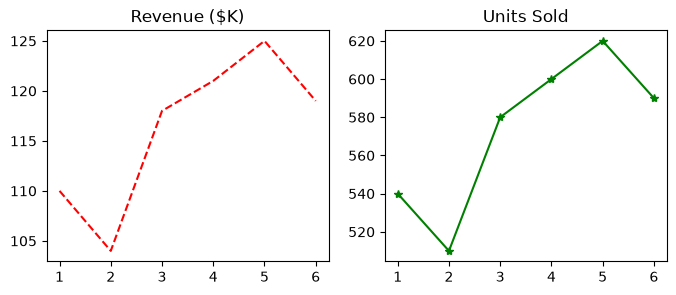

In [9]:
### plt.subplot(nrows, ncols, plot_number)   ### when you want multiple plots in one figure
### order is important, plot after subplot
month = np.arange(1, 7)
revenue = np.array([110, 104, 118, 121, 125, 119])   ### $K
units = np.array([540, 510, 580, 600, 620, 590])     ### units sold

plt.figure(figsize=(8,3))          ### create a figure first with specified size

plt.subplot(1, 2, 1)               ### subplot (axes) 1 of 1 row, 2 columns
plt.plot(month, revenue, 'r--')    ### 'r--' means red dashed line
plt.title('Revenue ($K)')

plt.subplot(1, 2, 2)               ### subplot (axes) 2 of 1 row, 2 columns
plt.plot(month, units, 'g*-')      ### 'g*-' means green line with star markers
plt.title('Units Sold');

In [10]:
### Exercise: Multiple Subplots with plt.subplot()
#   1. Create month = np.arange(1, 7),
#      online = np.array([82, 90, 97, 105, 118, 126]), and
#      in_store = np.array([140, 136, 131, 129, 124, 120]).
#   2. Use plt.figure(figsize=(8, 3)) to set the figure size.
#   3. In subplot position (1, 2, 1), plot month vs online with 'b-' and title "Online Sales".
#   4. In subplot position (1, 2, 2), plot month vs in_store with 'g--' and title "In-Store Sales".
### Your code starts here.




### Your code ends here.

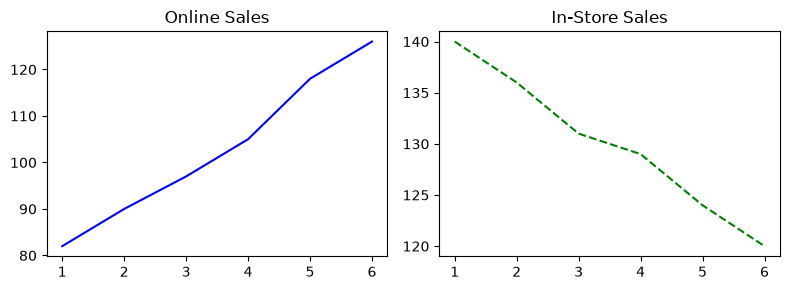

In [11]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
online = np.array([82, 90, 97, 105, 118, 126])
in_store = np.array([140, 136, 131, 129, 124, 120])

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(month, online, 'b-')
plt.title('Online Sales')
plt.subplot(1, 2, 2)
plt.plot(month, in_store, 'g--')
plt.title('In-Store Sales')
plt.tight_layout()
plt.show()